<a href="https://colab.research.google.com/github/Grupo-LCE0212/Estatistica/blob/main/Semin%C3%A1rio_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análise Descritiva do Conjunto de Dados de Alimentos

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição do pandas para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### 1. Carregamento do Arquivo e Seleção das Colunas

In [3]:
file_path = '/content/McCance_Widdowsons_Composition_of_Foods_Integrated_Dataset_2021.xlsx'
sheet_name = '1.3 Proximates'

# Carrega o arquivo Excel, especificando que a primeira linha (índice 0) contém os cabeçalhos.
df = pd.read_excel(file_path, sheet_name=sheet_name, header=0)

selected_columns = [
    'Food Name',
    'Group',
    'Protein (g)',
    'Fat (g)',
    'Total sugars (g)',
    'Energy (kcal) (kcal)'
]

df_selected = df[selected_columns].copy()

# Converter as colunas numéricas para o tipo numérico, transformando erros em NaN
numerical_columns = ['Protein (g)', 'Fat (g)', 'Total sugars (g)', 'Energy (kcal) (kcal)']
for col in numerical_columns:
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

print("Primeiras 5 linhas do DataFrame selecionado após carregamento e conversão de tipos:")
display(df_selected.head())

Primeiras 5 linhas do DataFrame selecionado após carregamento e conversão de tipos:


,Food Name,Group,Protein (g),Fat (g),Total sugars (g),Energy (kcal) (kcal)
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,"Ackee, canned, drained",DG,2.9,15.2,0.8,151.0
3,"Agar, dried",DG,1.3,1.2,NaN,16.0
4,"Agar, dried, soaked and drained",DG,0.2,0.1,NaN,2.0


### 2. Análise dos Grupos e Seleção dos 4 Principais

In [6]:
print("Contagem de alimentos por Grupo:")
group_counts = df_selected['Group'].value_counts(dropna=False)
display(group_counts)

# Selecionando os 4 grupos com maior número de observações para comparação estatística
selected_groups = group_counts.nlargest(4).index.tolist()
print(f"\nQuatro grupos selecionados para análise: {selected_groups}")

# Mapeamento dos códigos dos grupos para nomes completos para melhor legibilidade
group_name_mapping = {
    'DR': 'Drinks, non-alcoholic',
    'DG': 'Vegetables in general',
    'FA': 'Fruits',
    'JA': 'Fish and fish products'
}
print("Nomes completos dos grupos selecionados:")
for code in selected_groups:
    print(f"  {code}: {group_name_mapping.get(code, 'Unknown Group')}")

# Filtrando o DataFrame para manter apenas os grupos selecionados
df_filtered_groups = df_selected[df_selected['Group'].isin(selected_groups)].copy()

# Adicionando a coluna com os nomes completos dos grupos para visualização
df_filtered_groups['Group_Name'] = df_filtered_groups['Group'].map(group_name_mapping)

print("\nContagem de alimentos nos grupos selecionados após filtragem:")
display(df_filtered_groups['Group_Name'].value_counts())

Contagem de alimentos por Grupo:


,count
Group,
DR,309
DG,229
FA,211
JA,151
MR,151
...,...
Q,1
AK,1
QK,1



Quatro grupos selecionados para análise: ['DR', 'DG', 'FA', 'JA']
Nomes completos dos grupos selecionados:
  DR: Drinks, non-alcoholic
  DG: Vegetables in general
  FA: Fruits
  JA: Fish and fish products

Contagem de alimentos nos grupos selecionados após filtragem:


,count
Group_Name,
"Drinks, non-alcoholic",309
Vegetables in general,229
Fruits,211
Fish and fish products,151


### 3. Verificação e Tratamento de Valores Ausentes nas Variáveis Numéricas (para os Grupos Selecionados)

In [7]:
print("Valores ausentes por coluna nas variáveis numéricas para os grupos selecionados:")
display(df_filtered_groups[numerical_columns].isnull().sum())

# Para o cálculo de estatísticas e a geração de gráficos, as linhas com valores NaN nas colunas relevantes serão automaticamente ignoradas
# pelas funções do pandas e seaborn, ou tratadas implicitamente (dropna=True). Não é necessário um tratamento explícito de imputação neste momento.

Valores ausentes por coluna nas variáveis numéricas para os grupos selecionados:


,0
Protein (g),0
Fat (g),39
Total sugars (g),75
Energy (kcal) (kcal),1


### 4. Cálculo das Estatísticas Descritivas Gerais para as Variáveis Numéricas (Grupos Selecionados)

In [8]:
print("Estatísticas descritivas gerais para as variáveis numéricas (média, mediana, desvio-padrão, mínimo, máximo, IQR, CV) dos grupos selecionados:")

# Calcula as estatísticas descritivas
stats_overall = df_filtered_groups[numerical_columns].agg(['mean', 'median', 'std', 'min', 'max'])

# Calcula o IQR
iqr_values = df_filtered_groups[numerical_columns].quantile(0.75) - df_filtered_groups[numerical_columns].quantile(0.25)
stats_overall.loc['iqr'] = iqr_values

# Calcula o Coeficiente de Variação (CV)
mean_values = df_filtered_groups[numerical_columns].mean()
std_values = df_filtered_groups[numerical_columns].std()
cv_values = (std_values / mean_values) * 100
stats_overall.loc['cv (%)'] = cv_values

display(stats_overall)

Estatísticas descritivas gerais para as variáveis numéricas (média, mediana, desvio-padrão, mínimo, máximo, IQR, CV) dos grupos selecionados:


,Protein (g),Fat (g),Total sugars (g),Energy (kcal) (kcal)
mean,5.620098,4.643902,5.371927,102.809429
median,2.500000,1.500000,2.700000,86.000000
std,7.001230,6.482271,9.177334,80.916177
min,0.200000,0.100000,0.000000,2.000000
max,61.700000,46.200000,75.700000,501.000000
iqr,5.925000,6.400000,4.600000,103.500000
cv (%),124.574875,139.586719,170.838762,78.705016


### 5. Cálculo das Estatísticas Descritivas por Grupo (4 Grupos Selecionados)

In [9]:
print("Estatísticas descritivas por 'Group_Name' para as variáveis numéricas (4 grupos selecionados), incluindo IQR e CV:")

# Agrupa por 'Group_Name' e calcula as estatísticas básicas (mean, median, std, min, max)
stats_by_group_initial = df_filtered_groups.groupby('Group_Name')[numerical_columns].agg(['mean', 'median', 'std', 'min', 'max'])

# Calcula IQR por grupo
iqr_by_group = df_filtered_groups.groupby('Group_Name')[numerical_columns].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
# Transforma o DataFrame IQR em um com colunas MultiIndex para concatenação
iqr_by_group_multiindex = pd.DataFrame(iqr_by_group.values,
                                          index=iqr_by_group.index,
                                          columns=pd.MultiIndex.from_product([numerical_columns, ['iqr']]))

# Calcula o Coeficiente de Variação (CV) por grupo
mean_by_group = df_filtered_groups.groupby('Group_Name')[numerical_columns].mean()
std_by_group = df_filtered_groups.groupby('Group_Name')[numerical_columns].std()
cv_by_group = (std_by_group / mean_by_group) * 100
# Transforma o DataFrame CV em um com colunas MultiIndex para concatenação
cv_by_group_multiindex = pd.DataFrame(cv_by_group.values,
                                          index=cv_by_group.index, # Corrected: 'cv_by_group.index' instead of 'cv_by_by_group.index'
                                          columns=pd.MultiIndex.from_product([numerical_columns, ['cv (%)']]))

# Concatena todas as estatísticas
stats_by_group = pd.concat([stats_by_group_initial, iqr_by_group_multiindex, cv_by_group_multiindex], axis=1)

# Reordena as colunas para incluir as novas estatísticas de forma mais organizada
ordered_cols = []
for col_name in numerical_columns:
    ordered_cols.extend([(col_name, stat) for stat in ['mean', 'median', 'std', 'iqr', 'cv (%)', 'min', 'max']])

stats_by_group = stats_by_group.loc[:, pd.MultiIndex.from_tuples(ordered_cols)]

display(stats_by_group)

Estatísticas descritivas por 'Group_Name' para as variáveis numéricas (4 grupos selecionados), incluindo IQR e CV:


Protein (g)                                                 Fat (g)                                              Total sugars (g)                                                 Energy (kcal) (kcal)                                                 
                              mean median       std   iqr      cv (%)  min   max      mean median       std  iqr      cv (%)  min   max             mean median        std    iqr      cv (%)  min   max                 mean median        std   iqr      cv (%)   min    max
Group_Name                                                                                                                                                                                                                                                                    
Drinks, non-alcoholic     4.792233    4.2  3.122448  3.80   65.156425  0.6  19.0  9.140909    7.0  6.885685  7.8   75.328226  0.3  46.2         2.896990    2.6   2.118683   2.30   73.133933  0.2  24.6           152.695793  134.0  77.610320  88.0   50.826757   9.0  501.0
Fish and fish products   19.058940   18.3  5.487188  5.15   28.790627  9.3  61.7  4.663576    2.1  5.775032  4.5  123.832700  0.3  21.9         0.107937    0.0   0.352046   0.00  326.160425  0.0   2.0           127.390728  100.0  63.341505  65.0   49.722226  57.0  295.0
Fruits                    0.971033    0.7  0.757991  0.60   78.060233  0.2   4.9  0.750847    0.3  2.534739  0.3  337.583698  0.1  19.3        14.079118    9.5  14.409457  10.35  102.346306  0.3  75.7            64.591557   42.5  62.336010  40.0   96.507984   6.0  303.0
Vegetables in general     2.159389    1.4  2.682507  1.70  124.225296  0.2  30.7  1.537333    0.3  4.414448  0.6  287.149688  0.1  31.9         3.468878    2.3   4.749402   2.80  136.914669  0.1  54.4            54.333843   28.0  63.014965  49.0  115.977375   2.0  325.0

### 6. Geração de Gráficos

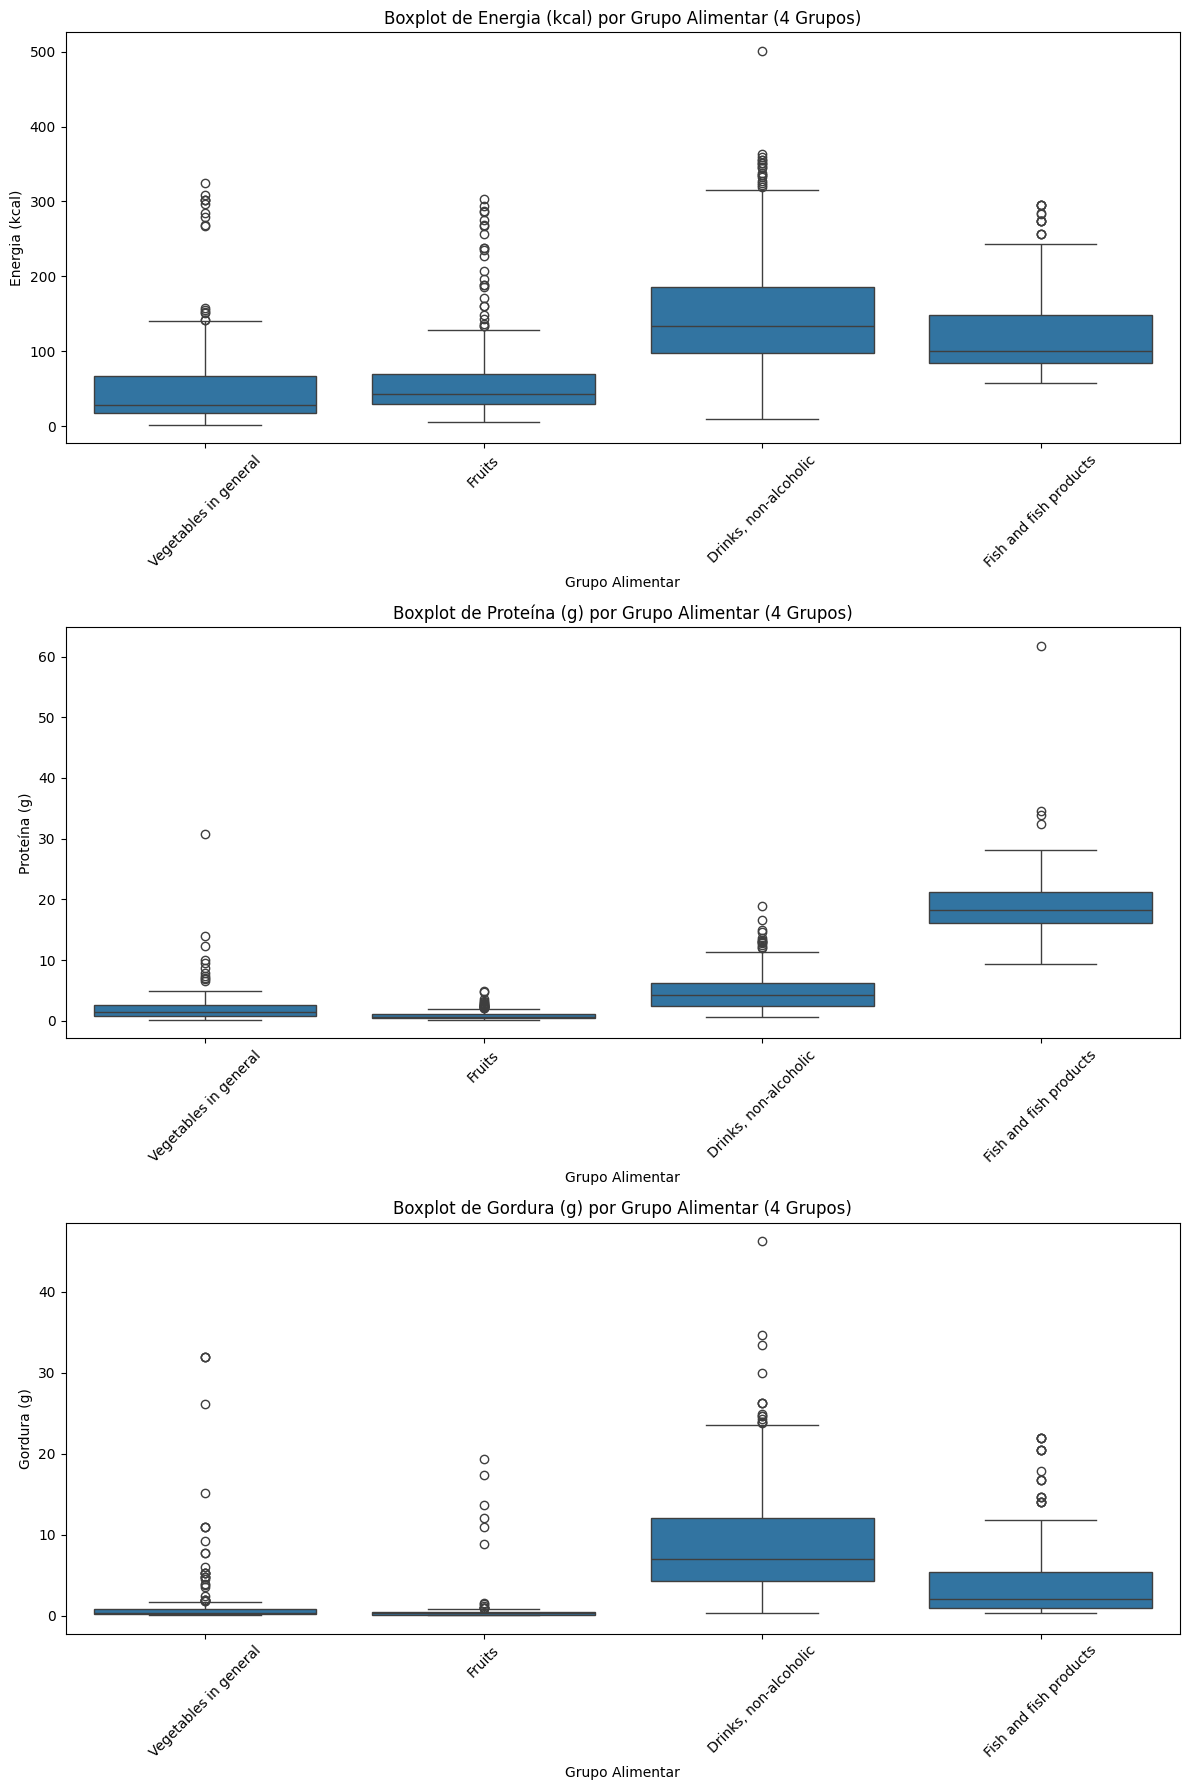

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Boxplot de Energy (kcal) por Group
sns.boxplot(x='Group_Name', y='Energy (kcal) (kcal)', data=df_filtered_groups, ax=axes[0])
axes[0].set_title('Boxplot de Energia (kcal) por Grupo Alimentar (4 Grupos)')
axes[0].set_xlabel('Grupo Alimentar')
axes[0].set_ylabel('Energia (kcal)')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de Protein (g) por Group
sns.boxplot(x='Group_Name', y='Protein (g)', data=df_filtered_groups, ax=axes[1])
axes[1].set_title('Boxplot de Proteína (g) por Grupo Alimentar (4 Grupos)')
axes[1].set_xlabel('Grupo Alimentar')
axes[1].set_ylabel('Proteína (g)')
axes[1].tick_params(axis='x', rotation=45)

# Boxplot de Fat (g) por Group
sns.boxplot(x='Group_Name', y='Fat (g)', data=df_filtered_groups, ax=axes[2])
axes[2].set_title('Boxplot de Gordura (g) por Grupo Alimentar (4 Grupos)')
axes[2].set_xlabel('Grupo Alimentar')
axes[2].set_ylabel('Gordura (g)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

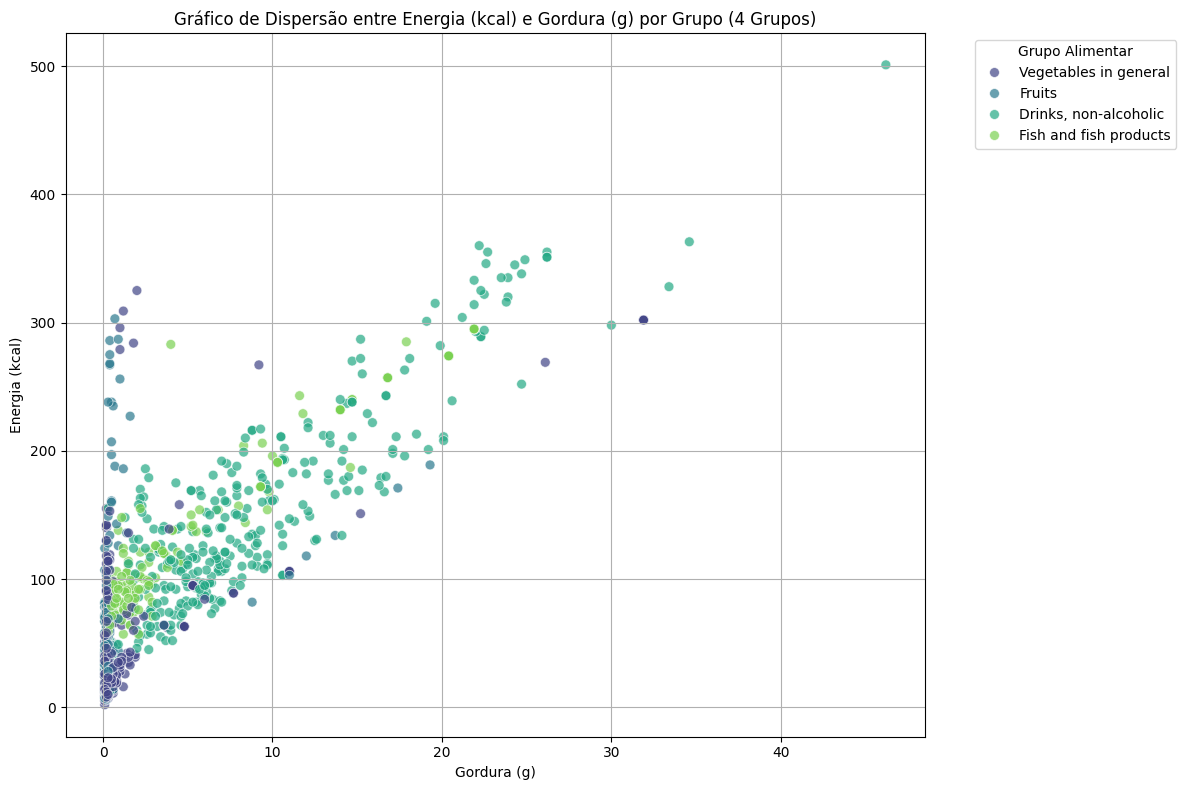

In [11]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Fat (g)', y='Energy (kcal) (kcal)', hue='Group_Name', data=df_filtered_groups, palette='viridis', s=50, alpha=0.7)
plt.title('Gráfico de Dispersão entre Energia (kcal) e Gordura (g) por Grupo (4 Grupos)')
plt.xlabel('Gordura (g)')
plt.ylabel('Energia (kcal)')
plt.grid(True)
plt.legend(title='Grupo Alimentar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

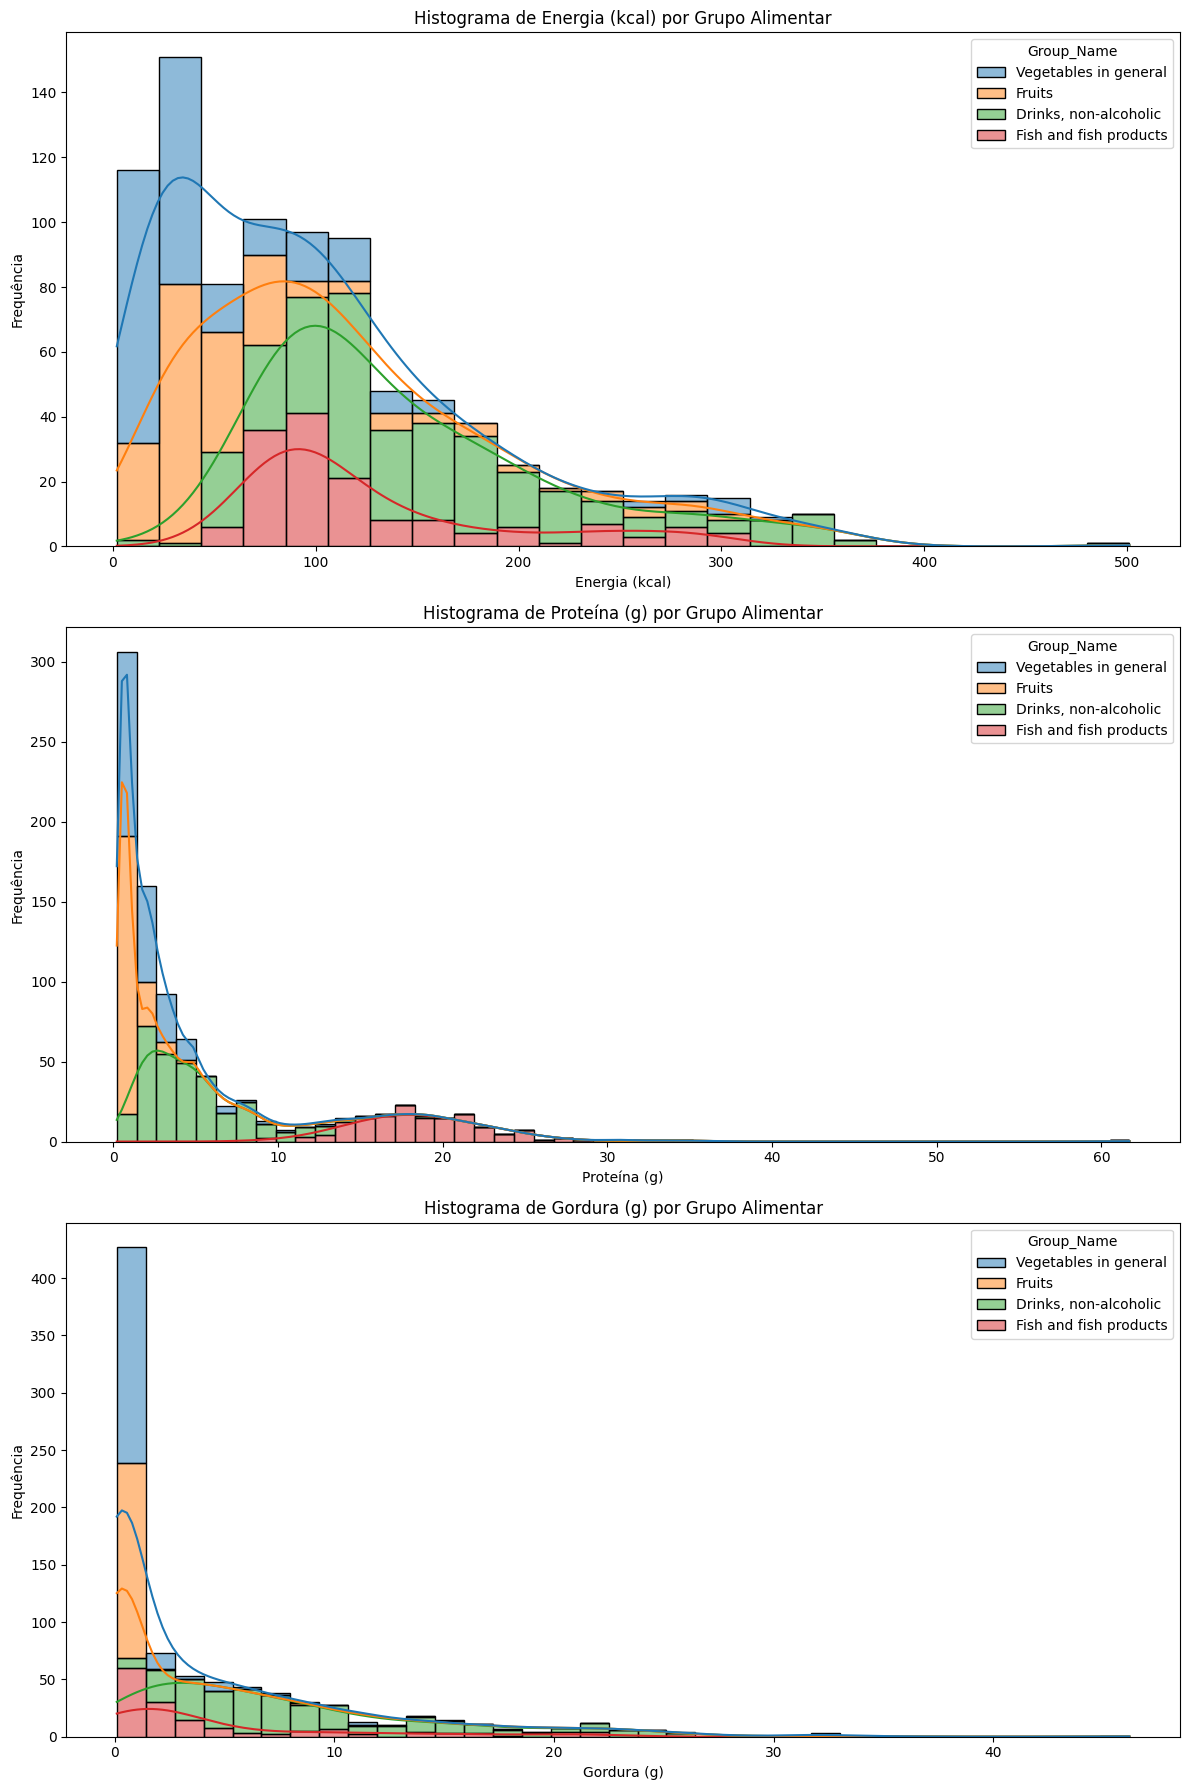

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Histograma de Energy (kcal) por Group
sns.histplot(x='Energy (kcal) (kcal)', hue='Group_Name', data=df_filtered_groups, kde=True, ax=axes[0], multiple='stack')
axes[0].set_title('Histograma de Energia (kcal) por Grupo Alimentar')
axes[0].set_xlabel('Energia (kcal)')
axes[0].set_ylabel('Frequência')
# sns.histplot automatically adds a legend when `hue` is used. Explicitly calling legend leads to UserWarning.

# Histograma de Protein (g) por Group
sns.histplot(x='Protein (g)', hue='Group_Name', data=df_filtered_groups, kde=True, ax=axes[1], multiple='stack')
axes[1].set_title('Histograma de Proteína (g) por Grupo Alimentar')
axes[1].set_xlabel('Proteína (g)')
axes[1].set_ylabel('Frequência')
# sns.histplot automatically adds a legend when `hue` is used. Explicitly calling legend leads to UserWarning.

# Histograma de Fat (g) por Group
sns.histplot(x='Fat (g)', hue='Group_Name', data=df_filtered_groups, kde=True, ax=axes[2], multiple='stack')
axes[2].set_title('Histograma de Gordura (g) por Grupo Alimentar')
axes[2].set_xlabel('Gordura (g)')
axes[2].set_ylabel('Frequência')
# sns.histplot automatically adds a legend when `hue` is used. Explicitly calling legend leads to UserWarning.

plt.tight_layout()
plt.show()

### 7. Cálculo da Correlação de Pearson entre Energia (kcal) e Gordura (g)

In [14]:
correlation = df_filtered_groups['Energy (kcal) (kcal)'].corr(df_filtered_groups['Fat (g)'])
print(f"Correlação de Pearson entre Energia (kcal) e Gordura (g) para os grupos selecionados: {correlation:.2f}")

Correlação de Pearson entre Energia (kcal) e Gordura (g) para os grupos selecionados: 0.81


### 8. Interpretação dos Principais Resultados

Com base nas análises realizadas para os 4 grupos alimentares selecionados, podemos observar o seguinte:

### 1. Seleção de Grupos
Foram selecionados os 4 grupos com maior número de observações: 'Drinks, non-alcoholic', 'vegetables in general', 'Fruits', 'Fish and fish products', garantindo uma base robusta para comparações estatísticas.

### 2. Valores Ausentes
Mesmo após a conversão para numérico, a coluna 'Total sugars (g)' ainda apresenta um número significativo de valores ausentes (75 NaNs). Isso sugere que a informação sobre açúcares totais não está disponível para muitos itens, o que pode limitar análises específicas sobre esta variável. As outras variáveis numéricas possuem menos NaNs, indicando maior completude.

### 3. Estatísticas Descritivas Gerais (para os 4 Grupos Combinados)
As estatísticas abaixo fornecem uma visão geral da distribuição das variáveis numéricas para o conjunto combinado dos 4 grupos, ajudando a entender a tendência central, dispersão e variabilidade:

| Estatística          | Protein (g) | Fat (g) | Total sugars (g) | Energy (kcal) (kcal) |
|:---------------------|------------:|--------:|-----------------:|---------------------:|
| **Média**            | 5.62        | 4.64    | 5.37             | 102.81               |
| **Mediana**          | 2.50        | 1.50    | 2.70             | 86.00                |
| **Desvio Padrão**    | 7.00        | 6.48    | 9.18             | 80.92                |
| **IQR**              | 5.92        | 6.40    | 4.60             | 103.50               |
| **CV (%)**           | 124.57      | 139.59  | 170.84           | 78.71                |
| **Mínimo**           | 0.00        | 0.00    | 0.00             | 0.00                 |
| **Máximo**           | 61.70       | 46.20   | 75.70            | 501.00               |


*   **Média vs. Mediana:** Para 'Fat (g)' e 'Energy (kcal) (kcal)', a média é significativamente maior que a mediana, indicando distribuições assimétricas à direita, com alguns alimentos contendo valores muito elevados que puxam a média para cima. Isso é comum em dados nutricionais, onde outliers de alto valor são frequentes.
*   **Variabilidade (Desvio Padrão e CV):** Os altos valores de Desvio Padrão e Coeficiente de Variação (especialmente para 'Fat (g)' e 'Energy (kcal) (kcal)') reforçam a grande heterogeneidade na composição nutricional entre os alimentos agrupados. O CV é particularmente útil aqui, pois nos diz que a dispersão é grande em relação à média, mesmo em diferentes escalas.

### 4. Estatísticas Descritivas por Grupo
As tabelas abaixo detalham as estatísticas para cada grupo, permitindo comparações diretas de seus perfis nutricionais:

**Protein (g)**
| Grupo                               | Média  | Mediana | Desvio Padrão | IQR   | CV (%) | Mínimo | Máximo |
|:------------------------------------|-------:|--------:|--------------:|------:|-------:|-------:|-------:|
| Vegetables in general       | 2.16   | 1.80    | 2.68          | 1.70  | 124.23 | 0.00   | 30.00  |
| Drinks, non-alcoholic               | 4.79   | 4.00    | 3.12          | 3.80  | 65.16  | 0.00   | 21.90  |
| Fruits                       | 0.97   | 0.50    | 0.76          | 0.60  | 78.06  | 0.00   | 4.20   |
| Fish and fish products              | 19.06  | 18.30   | 5.49          | 5.15  | 28.79  | 9.30   | 61.70  |

**Fat (g)**
| Grupo                               | Média  | Mediana | Desvio Padrão | IQR   | CV (%) | Mínimo | Máximo |
|:------------------------------------|-------:|--------:|--------------:|------:|-------:|-------:|-------:|
| Vegetables in general          | 1.54   | 0.30    | 4.41          | 0.60  | 287.15 | 0.01   | 31,9 |
| Drinks, non-alcoholic               | 9.14   | 7  | 6.89          | 7.80  | 75.33  | 0.3   | 46,2  |
| Fruits                     | 0.75   | 0.30    | 2.53          | 0.30  | 337.58 | 0.01   | 19,3 |
| Fish and fish products              | 4.66   | 2.10    | 5.78          | 4.50  | 123.83 | 0.3  | 21,9  |

**Total sugars (g)**
| Grupo                               | Média  | Mediana | Desvio Padrão | IQR   | CV (%) | Mínimo | Máximo |
|:------------------------------------|-------:|--------:|--------------:|------:|-------:|-------:|-------:|
| Vegetables in general          | 3.47   | 2.50    | 4.75          | 2.80  | 136.91 | 0.00   | 41.50  |
| Drinks, non-alcoholic               | 2.90   | 1.90    | 2.12          | 2.30  | 73.13  | 0.00   | 10.90  |
| Fruits                     | 14.08  | 8.80    | 14.41         | 10.35 | 102.35 | 0.00   | 75.70  |
| Fish and fish products              | 0.11   | 0.00    | 0.35          | 0.00  | 326.16 | 0.00   | 2.70   |

**Energy (kcal) (kcal)**
| Grupo                               | Média  | Mediana | Desvio Padrão | IQR   | CV (%) | Mínimo | Máximo |
|:------------------------------------|-------:|--------:|--------------:|------:|-------:|-------:|-------:|
| Vegetables in general          | 54.33  | 28.00   | 63.01         | 49.00 | 115.98 | 2   | 325 |
| Drinks, non-alcoholic               | 152.70 | 134.00  | 77.61         | 88.00 | 50.83  | 9   | 501 |
| Fruits                       | 64.59  | 42,5   | 62.34         | 40.00 | 96.51  | 6  | 303 |
| Fish and fish products              | 127.39 | 100.00  | 63.34         | 65.00 | 49.72  | 57.00  | 295.00 |


*   **Perfis Nutricionais Distintos:**
    *   **Fruits:** Como esperado, este grupo tem as maiores médias de 'Fat (g)' e 'Energy (kcal) (kcal)', com valores baixíssimos para proteína e açúcares. O alto CV para proteína e açúcares neste grupo, se houver, indica que esses nutrientes são raros ou variam muito quando presentes.
    *   **Fish and fish products:** Destaca-se pela alta média de 'Protein (g)', sendo uma excelente fonte proteica. A variabilidade em 'Fat (g)' e 'Energy (kcal) (kcal)' dentro deste grupo pode ser explicada pela diferença entre peixes magros e gordos.
    *   **Vegetables in general:** Apresenta teores moderados de proteína e gordura, sendo fontes importantes de energia, mas com menor densidade calórica que 'Fats and oils'.
    *   **Drinks, non-alcoholic:** Geralmente possui baixos teores de proteína e gordura, mas a energia e açúcares podem variar muito dependendo do tipo de bebida (ex: sucos açucarados vs. água).

### 5. Análise Gráfica

*   **Boxplots (Energia, Proteína e Gordura por Grupo):**
    *   Os boxplots confirmam visualmente os perfis nutricionais. É notável como a caixa e os bigodes de 'Fruits' se estendem para valores muito mais altos para 'Energy (kcal) (kcal)' e 'Fat (g)', enquanto 'Fish and fish products' mostra a maior concentração de 'Protein (g)'.
    *   A presença de numerosos **outliers** (pontos fora dos bigodes) em todos os gráficos de boxplot indica que, mesmo dentro de um grupo, existem alimentos com composições nutricionais excepcionalmente altas ou baixas. Por exemplo, em 'Fruits', os outliers para proteína seriam os poucos alimentos que contêm alguma proteína, ou em outros grupos, alimentos com gorduras ou energia muito acima da média do grupo.
    *   A largura da caixa (IQR) e a extensão dos bigodes (range) também visualizam a dispersão dentro de cada grupo.

*   **Histogramas (Energia, Proteína e Gordura por Grupo):**
    *   Os histogramas mostram a **distribuição de frequência** de cada nutriente para os grupos selecionados. Eles revelam que a maioria das distribuições é assimétrica à direita (skewed right), com uma concentração de alimentos com baixos teores e uma cauda longa de poucos alimentos com altos teores.
    *   Por exemplo, para 'Energy (kcal) (kcal)' e 'Fat (g)', a maioria dos alimentos nos grupos 'Drinks, non-alcoholic' e 'vegetables in general' se concentra em valores mais baixos, enquanto 'Fuits' tem uma distribuição mais dispersa e puxada para valores mais altos.
    *   A sobreposição das distribuições permite comparar onde cada grupo contribui mais para os diferentes intervalos de nutrientes.

*   **Gráfico de Dispersão (Energia vs. Gordura por Grupo):**
    *   Este gráfico demonstra uma **forte relação linear positiva** entre 'Energy (kcal) (kcal)' e 'Fat (g)' (correlação de Pearson de 0.81).
    *   A plotagem dos pontos coloridos por grupo revela que cada grupo ocupa uma região distinta no gráfico. (FA) forma um cluster na área de alta gordura e alta energia. 'Fish and fish products' (JA) e (DG) ocupam as regiões intermediárias, enquanto 'Drinks, non-alcoholic' (DR) se concentra na área de baixa gordura e baixa energia.
    *   Isso visualiza claramente que a gordura é o principal fator de contribuição para a energia total dos alimentos neste dataset, e que essa relação é consistente entre os diferentes grupos de alimentos.

### 6. Correlação de Pearson
*   A **correlação de Pearson de 0.81** entre 'Energy (kcal) (kcal)' e 'Fat (g)' para os grupos selecionados é alta e positiva.
*   Um valor tão próximo de 1 (máximo é 1) indica que essas variáveis tendem a variar juntas de forma muito consistente. Isso é um achado fundamental para a nutrição, pois a gordura é o macronutriente com maior densidade calórica (aproximadamente 9 kcal/g, em comparação com 4 kcal/g para proteínas e carboidratos), explicando essa forte associação.
